# Student Performance Prediction 📊 - Exploratory Data Analysis and Machine Learning

## About this Notebook

In this notebook, I explored the Student Performance dataset to understand the factors that may affect students' exam scores. I checked the data, handled missing and invalid values, studied different features using visualizations, and built a Linear Regression model to predict exam scores.

## Dataset Information

This dataset contains information about students and different factors related to their academic performance.

### Target Variable

- Exam_Score – Final exam score of the student.

### Features

- Hours_Studied – Hours spent studying.
- Attendance – Attendance percentage.
- Parental_Involvement – Level of parental involvement.
- Access_to_Resources – Availability of study resources.
- Extracurricular_Activities – Participation in extracurricular activities.
- Sleep_Hours – Average hours of sleep.
- Previous_Scores – Previous exam score.
- Motivation_Level – Student's motivation level.
- Internet_Access – Access to the internet.
- Tutoring_Sessions – Number of tutoring sessions.
- Family_Income – Family income level.
- Teacher_Quality – Quality of teaching.
- School_Type – Type of school.
- Peer_Influence – Influence of peers.
- Physical_Activity – Level of physical activity.
- Learning_Disabilities – Whether the student has a learning disability.
- Parental_Education_Level – Education level of parents.
- Distance_from_Home – Distance from home to school.
- Gender – Student's gender.

## Importing Required Libraries

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading

In [2]:
path='/kaggle/input/datasets/lainguyn123/student-performance-factors/StudentPerformanceFactors.csv'
df=pd.read_csv(path)
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [3]:
df.shape

(6607, 20)

In [4]:
df.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [6]:
df.dtypes

Hours_Studied                  int64
Attendance                     int64
Parental_Involvement          object
Access_to_Resources           object
Extracurricular_Activities    object
Sleep_Hours                    int64
Previous_Scores                int64
Motivation_Level              object
Internet_Access               object
Tutoring_Sessions              int64
Family_Income                 object
Teacher_Quality               object
School_Type                   object
Peer_Influence                object
Physical_Activity              int64
Learning_Disabilities         object
Parental_Education_Level      object
Distance_from_Home            object
Gender                        object
Exam_Score                     int64
dtype: object

In [7]:
df.describe(include='all')

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
count,6607.000000,6607.000000,6607,6607,6607,6607.00000,6607.000000,6607,6607,6607.000000,6607,6529,6607,6607,6607.000000,6607,6517,6540,6607,6607.000000
unique,NaN,NaN,3,3,2,NaN,NaN,3,2,NaN,3,3,2,3,NaN,2,3,3,2,NaN
top,NaN,NaN,Medium,Medium,Yes,NaN,NaN,Medium,Yes,NaN,Low,Medium,Public,Positive,NaN,No,High School,Near,Male,NaN
freq,NaN,NaN,3362,3319,3938,NaN,NaN,3351,6108,NaN,2672,3925,4598,2638,NaN,5912,3223,3884,3814,NaN
mean,19.975329,79.977448,NaN,NaN,NaN,7.02906,75.070531,NaN,NaN,1.493719,NaN,NaN,NaN,NaN,2.967610,NaN,NaN,NaN,NaN,67.235659
std,5.990594,11.547475,NaN,NaN,NaN,1.46812,14.399784,NaN,NaN,1.230570,NaN,NaN,NaN,NaN,1.031231,NaN,NaN,NaN,NaN,3.890456
min,1.000000,60.000000,NaN,NaN,NaN,4.00000,50.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,55.000000
25%,16.000000,70.000000,NaN,NaN,NaN,6.00000,63.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,NaN,NaN,65.000000
50%,20.000000,80.000000,NaN,NaN,NaN,7.00000,75.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,NaN,67.000000
75%,24.000000,90.000000,NaN,NaN,NaN,8.00000,88.000000,NaN,NaN,2.000000,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,69.000000


## Data Cleaning

In [8]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [9]:
round((df.isnull().sum()/df.shape[0])*100,2)

Hours_Studied                 0.00
Attendance                    0.00
Parental_Involvement          0.00
Access_to_Resources           0.00
Extracurricular_Activities    0.00
Sleep_Hours                   0.00
Previous_Scores               0.00
Motivation_Level              0.00
Internet_Access               0.00
Tutoring_Sessions             0.00
Family_Income                 0.00
Teacher_Quality               1.18
School_Type                   0.00
Peer_Influence                0.00
Physical_Activity             0.00
Learning_Disabilities         0.00
Parental_Education_Level      1.36
Distance_from_Home            1.01
Gender                        0.00
Exam_Score                    0.00
dtype: float64

In [10]:
df['Teacher_Quality']=df['Teacher_Quality'].fillna(df['Teacher_Quality'].mode()[0])

df['Parental_Education_Level']=df['Parental_Education_Level'].fillna(
    df['Parental_Education_Level'].mode()[0])

df['Distance_from_Home']=df['Distance_from_Home'].fillna(
    df['Distance_from_Home'].mode()[0])

<Axes: >

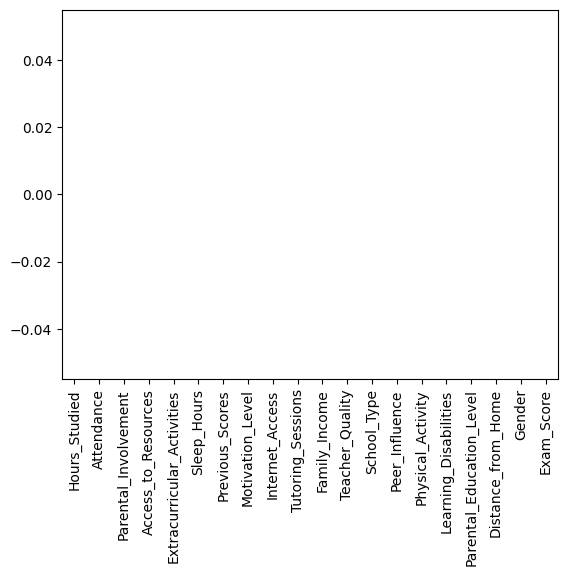

In [11]:
round((df.isnull().sum()/df.shape[0])*100,2).plot(kind='bar')

In [12]:
df.duplicated().sum()

np.int64(0)

## Exploratory Data Analysis

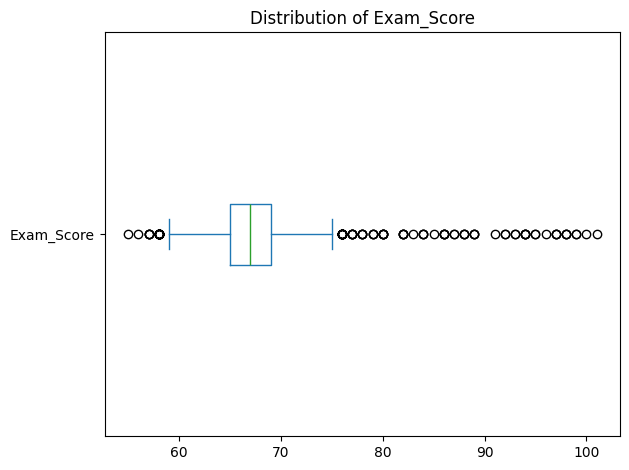

In [13]:
df['Exam_Score'].plot(kind='box',vert=False)
plt.title("Distribution of Exam_Score")
plt.tight_layout()
plt.show()

In [14]:
df['Exam_Score'].value_counts()

Exam_Score
68     759
66     751
67     717
65     679
69     624
70     542
64     501
71     408
63     371
72     304
62     264
61     171
73     141
74     106
60      77
75      48
59      40
58      22
76      16
80       5
77       5
94       4
86       4
82       4
78       4
57       4
84       3
79       3
89       3
98       3
88       3
97       3
95       2
93       2
87       2
99       2
92       2
83       1
100      1
55       1
101      1
91       1
96       1
85       1
56       1
Name: count, dtype: int64

In [15]:
df[df['Exam_Score']>100]

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
1525,27,98,Low,Medium,Yes,6,93,Low,No,5,High,High,Public,Positive,3,No,High School,Moderate,Female,101


In [16]:
df=df[df['Exam_Score']<101]

In [17]:
df['Exam_Score'].max()

100

### Handling Invalid Exam Scores

The `Exam_Score` column should have values between 0 and 100. During the data checking process, I found one record with an exam score of **101**, which is not a valid score.

I treated this as a data entry error and removed that record from the dataset before continuing with the analysis.

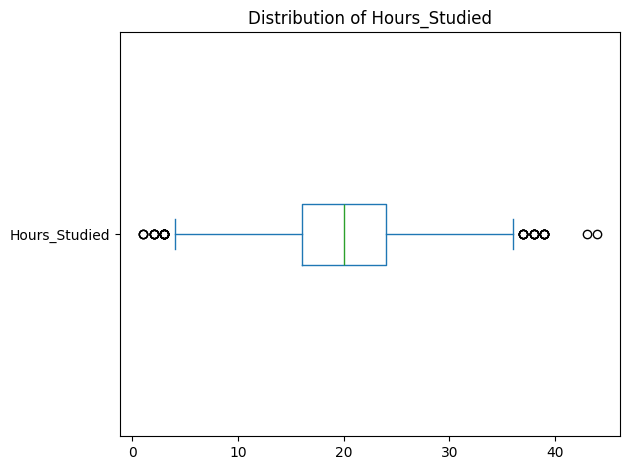

In [18]:
df['Hours_Studied'].plot(kind='box',vert=False)
plt.title("Distribution of Hours_Studied")
plt.tight_layout()
plt.show()

In [19]:
df['Hours_Studied'].value_counts()

Hours_Studied
20    465
19    441
21    431
23    411
22    402
18    401
17    381
24    357
16    351
15    315
25    289
14    269
26    263
27    228
13    218
12    192
28    171
11    146
29    134
30    123
10     94
9      86
31     77
8      58
32     54
7      51
33     40
34     29
5      21
35     20
4      17
6      17
3      12
36     11
38      7
39      7
2       6
37      6
1       3
43      1
44      1
Name: count, dtype: int64

In [20]:
df[df['Hours_Studied']>40]

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
209,43,86,High,Medium,Yes,7,97,Medium,Yes,2,Medium,High,Public,Positive,1,No,High School,Near,Female,78
2895,44,68,High,Low,No,9,75,Low,Yes,3,Medium,High,Private,Negative,2,No,High School,Moderate,Female,71


### Outlier Analysis - Hours Studied

The boxplot shows a few higher values such as 43 and 44 hours as outliers. However, these values are still possible and there is no clear evidence that they are data entry errors. Therefore, I decided to keep these observations in the dataset instead of removing them only because they were identified as statistical outliers.

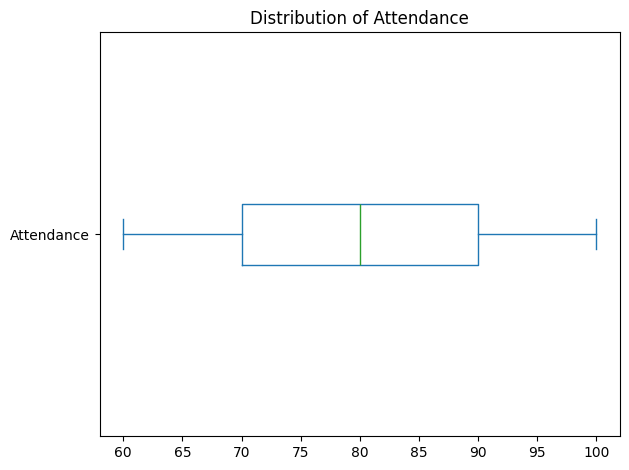

In [21]:
df['Attendance'].plot(kind='box',vert=False)
plt.title("Distribution of Attendance")
plt.tight_layout()
plt.show()

### Outlier Analysis - Attendance

The boxplot shows that the values in the `Attendance` column are within a reasonable range. There are no obvious invalid or extreme values.

Therefore, no values were removed from the `Attendance` column.

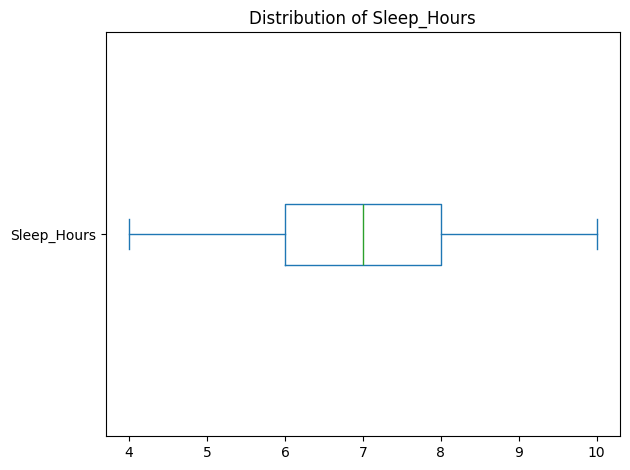

In [22]:
df['Sleep_Hours'].plot(kind='box',vert=False)
plt.title("Distribution of Sleep_Hours")
plt.tight_layout()
plt.show()

### Outlier Analysis - Sleep Hours

The boxplot shows that the `Sleep_Hours` values are within a reasonable range of 4 to 10 hours. There are no obvious invalid or extreme values, so no observations were removed from this column.

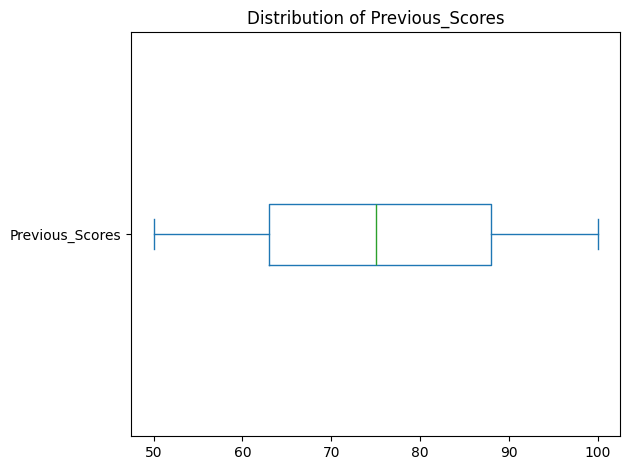

In [23]:
df['Previous_Scores'].plot(kind='box',vert=False)
plt.title("Distribution of Previous_Scores")
plt.tight_layout()
plt.show()

### Outlier Analysis - Previous Scores

The boxplot shows that the `Previous_Scores` values are within a reasonable range of 50 to 100. There are no obvious invalid or extreme values, so no observations were removed from this column.

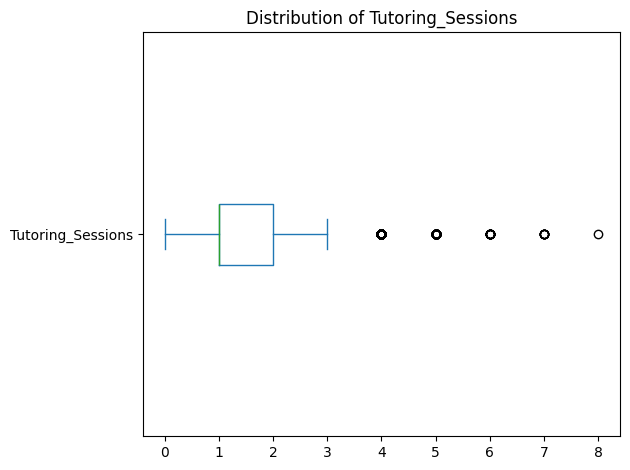

In [24]:
df['Tutoring_Sessions'].plot(kind='box',vert=False)
plt.title("Distribution of Tutoring_Sessions")
plt.tight_layout()
plt.show()

In [25]:
df['Tutoring_Sessions'].value_counts()

Tutoring_Sessions
1    2179
2    1649
0    1513
3     836
4     301
5     102
6      18
7       7
8       1
Name: count, dtype: int64

In [26]:
df[df['Tutoring_Sessions']>7]

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
2231,25,72,Low,Low,Yes,6,78,Low,Yes,8,Medium,High,Public,Positive,4,No,High School,Near,Male,69


### Outlier Analysis - Tutoring Sessions

The boxplot shows some higher values in the `Tutoring_Sessions` column. The maximum value is 8 sessions, and only one student has 8 tutoring sessions.

Although these values are less common, they are still possible and there is no clear evidence that they are incorrect. Therefore, I decided to keep these observations in the dataset.

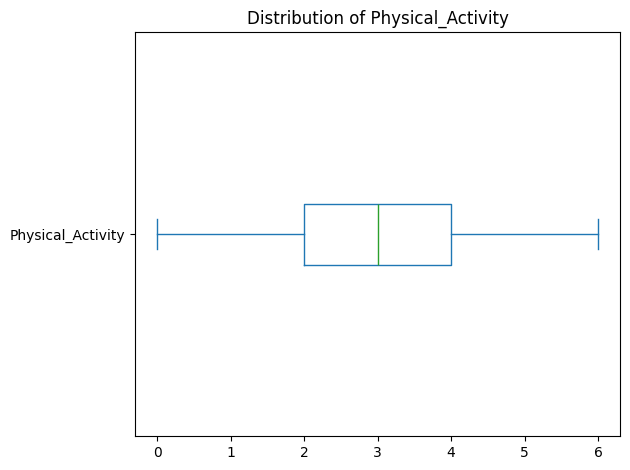

In [27]:
df['Physical_Activity'].plot(kind='box',vert=False)
plt.title("Distribution of Physical_Activity")
plt.tight_layout()
plt.show()

### Outlier Analysis - Physical Activity

The boxplot shows that the `Physical_Activity` values are within a reasonable range of 0 to 6 hours. There are no obvious invalid or extreme values, so no observations were removed from this column.

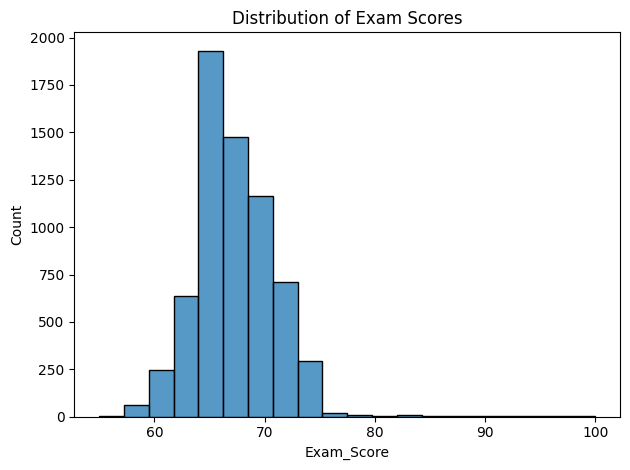

In [28]:
sns.histplot(data=df,x=df['Exam_Score'],bins=20)
plt.title('Distribution of Exam Scores')
plt.tight_layout()
plt.show()

### Exam Score Distribution

The histogram shows that most students have exam scores between 65 and 75. The highest number of students have scores around 68 to 71.

There are fewer students with very low or very high scores. The distribution has a slight right tail because a small number of students have higher scores.

This gives us a better understanding of the target variable before building the machine learning model.

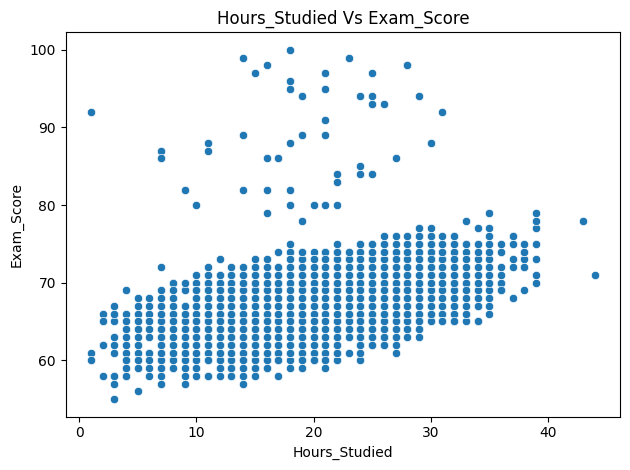

In [29]:
sns.scatterplot(data=df,x=df['Hours_Studied'],y=df['Exam_Score'])
plt.title('Hours_Studied Vs Exam_Score')
plt.tight_layout()
plt.show()

### Hours Studied vs Exam Score

The scatter plot shows a positive relationship between hours studied and exam score.

In general, students who study for more hours tend to get higher exam scores. However, the points are not perfectly aligned, which means other factors also affect the exam score.

Therefore, Hours_Studied appears to be an important factor for predicting Exam_Score.

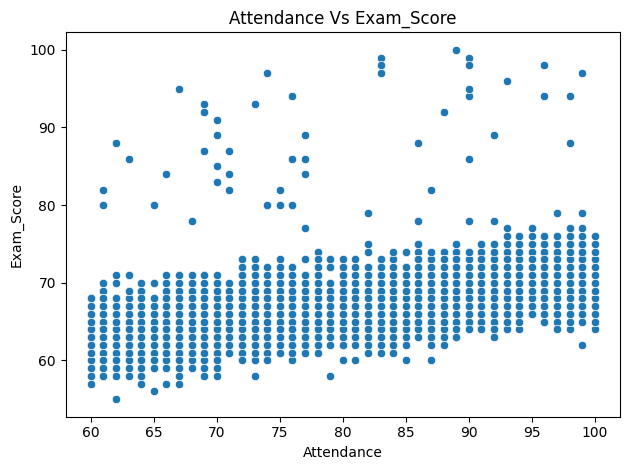

In [30]:
sns.scatterplot(data=df,x=df['Attendance'],y=df['Exam_Score'])
plt.title('Attendance Vs Exam_Score')
plt.tight_layout()
plt.show()

### Attendance vs Exam Score

The scatter plot shows a positive relationship between attendance and exam score.

In general, students with higher attendance tend to have slightly higher exam scores. However, the points are spread out, so attendance is not the only factor affecting the exam score.

Therefore, Attendance can be considered as one of the factors that may help in predicting Exam_Score.

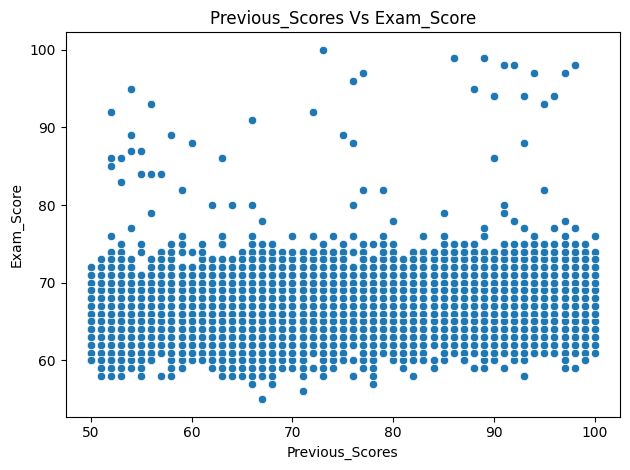

In [31]:
sns.scatterplot(data=df,x=df['Previous_Scores'],y=df['Exam_Score'])
plt.title('Previous_Scores Vs Exam_Score')
plt.tight_layout()
plt.show()

### Previous Scores vs Exam Score

The scatter plot shows a positive relationship between previous scores and exam scores.

Students with higher previous scores generally tend to have higher exam scores. However, the points are still spread out, which means previous scores are not the only factor affecting the final exam score.

Therefore, Previous_Scores can be considered an important factor for predicting Exam_Score.

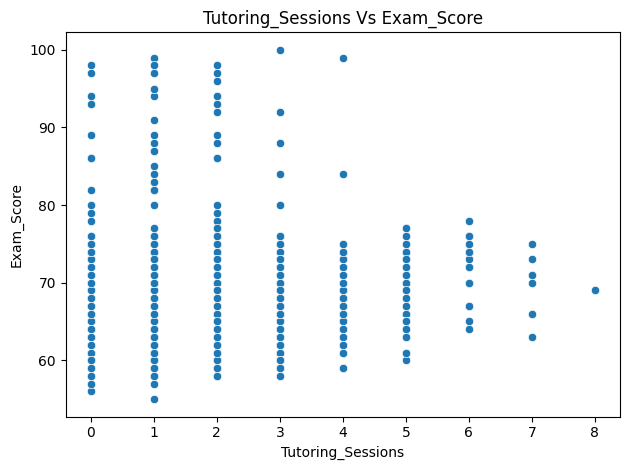

In [32]:
sns.scatterplot(data=df,x=df['Tutoring_Sessions'],y=df['Exam_Score'])
plt.title('Tutoring_Sessions Vs Exam_Score')
plt.tight_layout()
plt.show()

### Tutoring Sessions vs Exam Score

The scatter plot does not show a clear relationship between tutoring sessions and exam scores.

Most students have between 0 and 3 tutoring sessions, while a smaller number of students have more sessions. The exam scores are spread across different values, so having more tutoring sessions does not always result in a higher exam score.

Therefore, Tutoring_Sessions may have a limited effect on Exam_Score in this dataset.

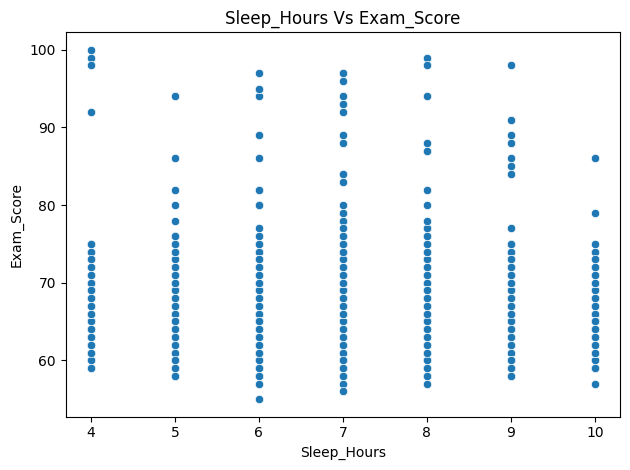

In [33]:
sns.scatterplot(data=df,x=df['Sleep_Hours'],y=df['Exam_Score'])
plt.title('Sleep_Hours Vs Exam_Score')
plt.tight_layout()
plt.show()

### Sleep Hours vs Exam Score

The scatter plot shows that there is no clear relationship between sleep hours and exam scores.

Students with different amounts of sleep can have both low and high exam scores. The points are widely spread across the graph.

Therefore, Sleep_Hours does not appear to be a strong factor for predicting Exam_Score by itself.

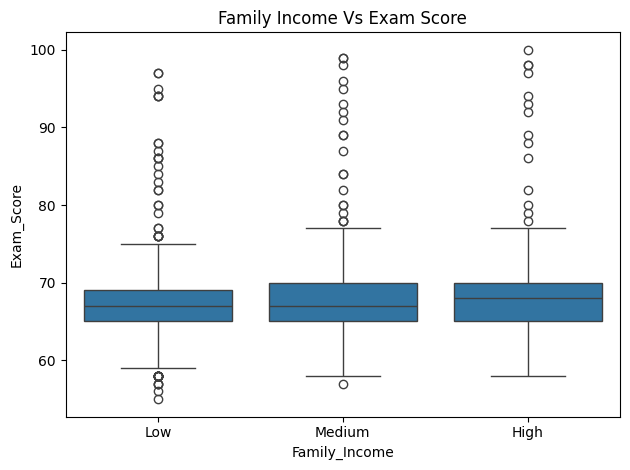

In [34]:
sns.boxplot(data=df, x='Family_Income', y='Exam_Score')
plt.title('Family Income Vs Exam Score')
plt.tight_layout()
plt.show()

### Family Income vs Exam Score

The box plot shows the distribution of exam scores for students from different family income groups.

The median exam scores of the Low, Medium, and High income groups are fairly close to each other. The High income group has a slightly higher median score, but there is a lot of overlap between the three groups.

Therefore, Family_Income may have some influence on Exam_Score, but it does not appear to be a very strong factor by itself.

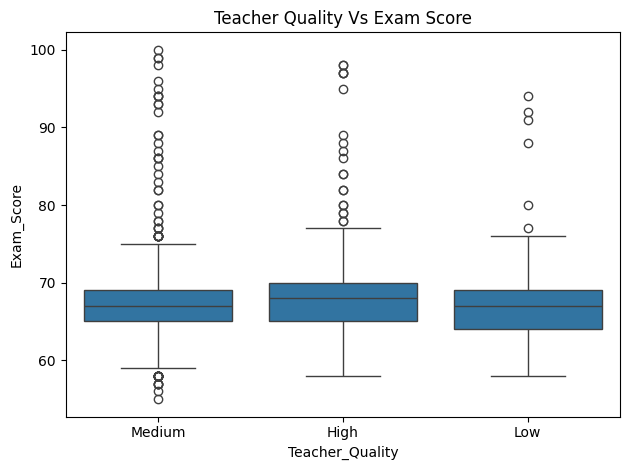

In [35]:
sns.boxplot(data=df, x='Teacher_Quality', y='Exam_Score')
plt.title('Teacher Quality Vs Exam Score')
plt.tight_layout()
plt.show()

### Teacher Quality vs Exam Score

The box plot shows the distribution of exam scores for students with different levels of teacher quality.

Students with High Teacher Quality have a slightly higher median exam score compared to Medium and Low Teacher Quality. However, the three groups have a lot of overlap.

This suggests that Teacher_Quality may have some influence on Exam_Score, but it is not the only factor affecting student performance.

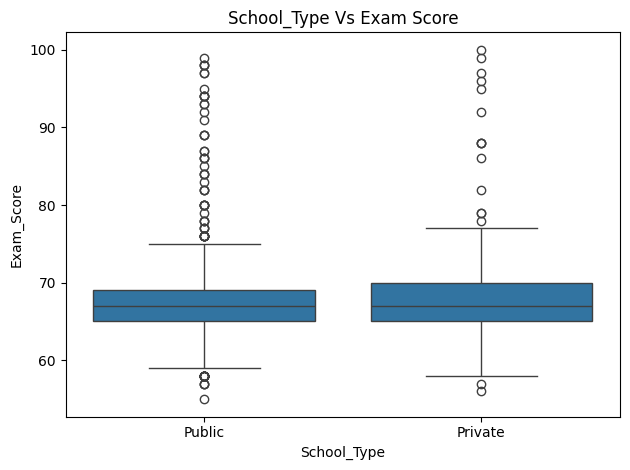

In [36]:
sns.boxplot(data=df, x='School_Type', y='Exam_Score')
plt.title('School_Type Vs Exam Score')
plt.tight_layout()
plt.show()

### School Type vs Exam Score

The box plot compares exam scores between Public and Private schools.

The median exam scores for both school types are very similar. The Private school group has a slightly higher median score than the Public school group.

Overall, the distributions are quite similar, which suggests that School_Type does not have a very strong effect on Exam_Score by itself.

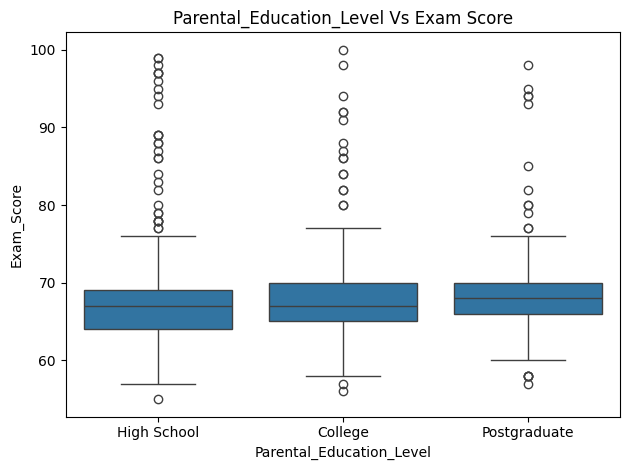

In [37]:
sns.boxplot(data=df, x='Parental_Education_Level', y='Exam_Score')
plt.title('Parental_Education_Level Vs Exam Score')
plt.tight_layout()
plt.show()

### Parental Education Level vs Exam Score

The box plot compares exam scores based on the education level of the student's parents.

Students whose parents have a Postgraduate education have a slightly higher median exam score. Students with parents having a College education have a similar median, while the High School group has a slightly lower median.

Overall, the differences between the groups are small, so Parental_Education_Level may have some influence on Exam_Score, but it is not the only factor affecting student performance.

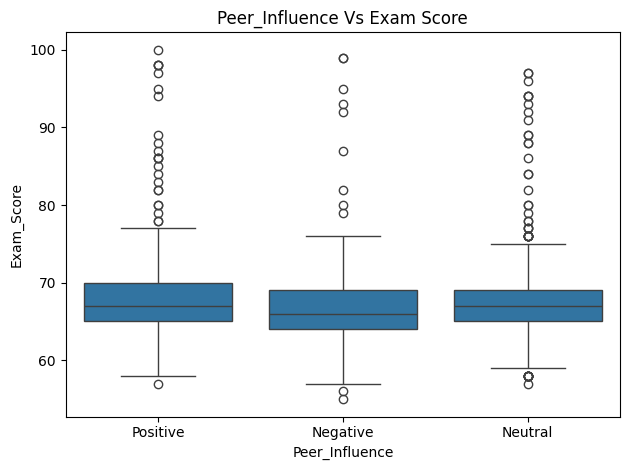

In [38]:
sns.boxplot(data=df, x='Peer_Influence', y='Exam_Score')
plt.title('Peer_Influence Vs Exam Score')
plt.tight_layout()
plt.show()

### Peer Influence vs Exam Score

The box plot compares exam scores for students with different types of peer influence.

Students with Positive and Neutral peer influence have very similar median exam scores. The Negative peer influence group has a slightly lower median score.

Overall, the differences are small, so Peer_Influence may have some effect on Exam_Score, but it is not the only factor affecting student performance.

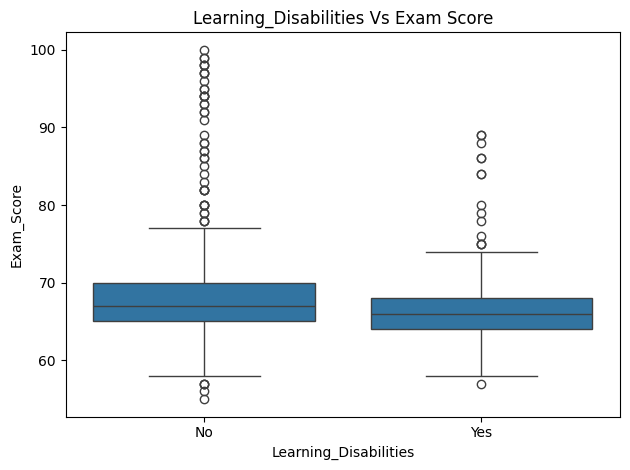

In [39]:
sns.boxplot(data=df, x='Learning_Disabilities', y='Exam_Score')
plt.title('Learning_Disabilities Vs Exam Score')
plt.tight_layout()
plt.show()

### Learning Disabilities vs Exam Score

The box plot compares exam scores of students with and without learning disabilities.

Students without learning disabilities have a slightly higher median exam score than students with learning disabilities.

The two groups still have a lot of overlap, so Learning_Disabilities may have some relationship with Exam_Score, but it is not the only factor affecting student performance.

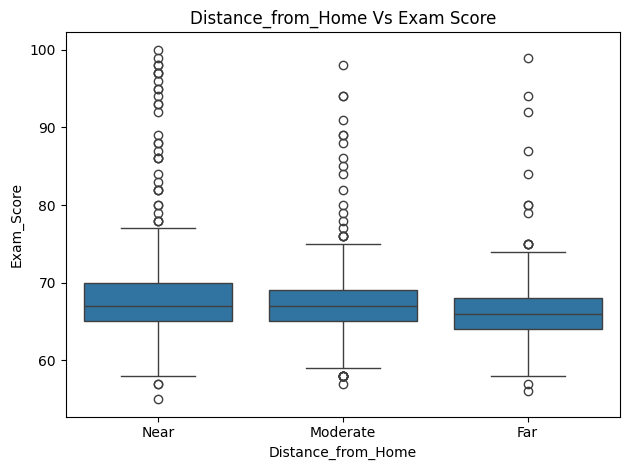

In [40]:
sns.boxplot(data=df, x='Distance_from_Home', y='Exam_Score')
plt.title('Distance_from_Home Vs Exam Score')
plt.tight_layout()
plt.show()

### Distance from Home vs Exam Score

The box plot compares exam scores based on the distance students travel from home to school.

Students living Near the school have the highest median exam score. The Moderate group has a slightly lower median, while the Far group has the lowest median score.

This suggests that students who live farther from school may have slightly lower exam scores. However, the three groups still have a lot of overlap, so Distance_from_Home is not the only factor affecting Exam_Score.


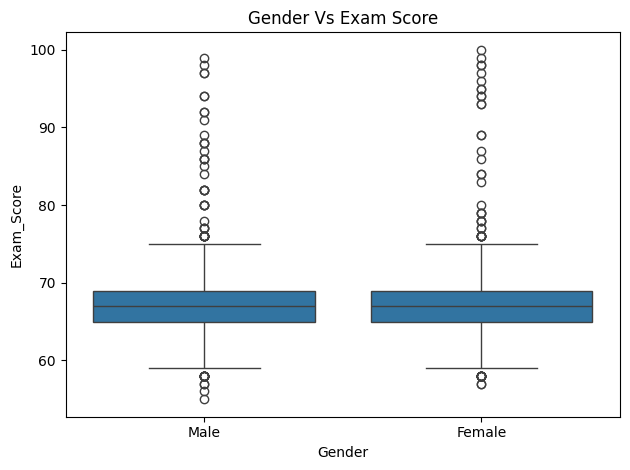

In [41]:
sns.boxplot(data=df, x='Gender', y='Exam_Score')
plt.title('Gender Vs Exam Score')
plt.tight_layout()
plt.show()

### Gender vs Exam Score

The box plot compares exam scores between male and female students.

The median exam scores for both groups are almost the same, and their overall distributions are also very similar.

This suggests that Gender does not have a strong relationship with Exam_Score in this dataset.

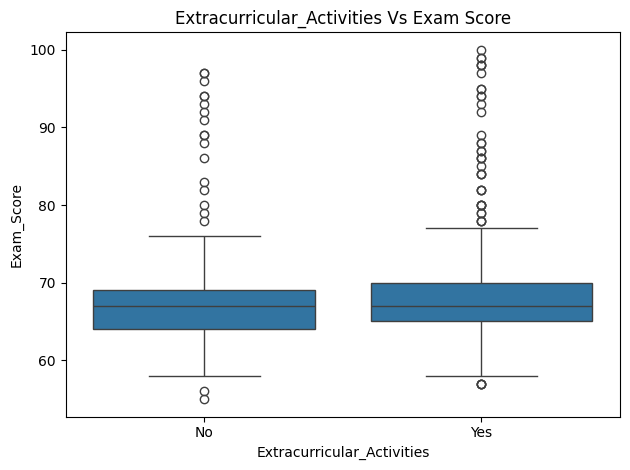

In [42]:
sns.boxplot(data=df, x='Extracurricular_Activities', y='Exam_Score')
plt.title('Extracurricular_Activities Vs Exam Score')
plt.tight_layout()
plt.show()

## Correlation Analysis


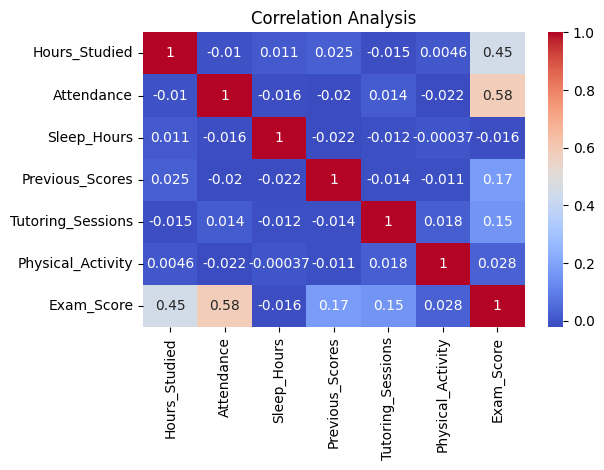

In [43]:
corr_matrix=df.select_dtypes('number').corr()
sns.heatmap(data=corr_matrix,annot=True,cmap='coolwarm')
plt.title('Correlation Analysis')
plt.tight_layout()
plt.show()

## Encoding

In [44]:
df_encoded=pd.get_dummies(df,columns=['Parental_Involvement','Access_to_Resources','Extracurricular_Activities','Motivation_Level','Internet_Access','Family_Income','Teacher_Quality','School_Type','Peer_Influence','Learning_Disabilities','Parental_Education_Level','Distance_from_Home','Gender'],drop_first=True,dtype='int')
df_encoded.head()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score,Parental_Involvement_Low,Parental_Involvement_Medium,Access_to_Resources_Low,...,Teacher_Quality_Medium,School_Type_Public,Peer_Influence_Neutral,Peer_Influence_Positive,Learning_Disabilities_Yes,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Distance_from_Home_Moderate,Distance_from_Home_Near,Gender_Male
0,23,84,7,73,0,3,67,1,0,0,...,1,1,0,1,0,1,0,0,1,1
1,19,64,8,59,2,4,61,1,0,0,...,1,1,0,0,0,0,0,1,0,0
2,24,98,7,91,2,4,74,0,1,0,...,1,1,1,0,0,0,1,0,1,1
3,29,89,8,98,1,4,71,1,0,0,...,1,1,0,0,0,1,0,1,0,1
4,19,92,6,65,3,4,70,0,1,0,...,0,1,1,0,0,0,0,0,1,0


In [45]:
df_encoded.columns

Index(['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
       'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score',
       'Parental_Involvement_Low', 'Parental_Involvement_Medium',
       'Access_to_Resources_Low', 'Access_to_Resources_Medium',
       'Extracurricular_Activities_Yes', 'Motivation_Level_Low',
       'Motivation_Level_Medium', 'Internet_Access_Yes', 'Family_Income_Low',
       'Family_Income_Medium', 'Teacher_Quality_Low', 'Teacher_Quality_Medium',
       'School_Type_Public', 'Peer_Influence_Neutral',
       'Peer_Influence_Positive', 'Learning_Disabilities_Yes',
       'Parental_Education_Level_High School',
       'Parental_Education_Level_Postgraduate', 'Distance_from_Home_Moderate',
       'Distance_from_Home_Near', 'Gender_Male'],
      dtype='object')

## Separating Features and Target Variable


In [46]:
X=df_encoded.drop(columns=['Exam_Score'],axis=1)
y=df_encoded['Exam_Score']

## Splitting the Dataset


In [47]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.15,random_state=42)

## Building the Linear Regression Model

In [48]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()

In [49]:
model.fit(X_train,y_train)

LinearRegression()

In [50]:
result=model.predict(X_test)

## Model Evaluation

In [51]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae=mean_absolute_error(y_test, result)
mse=mean_squared_error(y_test, result)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, result)
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)
print("R2 Score:", r2 * 100, "%")

Mean Absolute Error: 0.4228038980105721
Mean Squared Error: 2.7962223661854995
Root Mean Squared Error: 1.6721908880823084
R2 Score: 0.7900663198903146
R2 Score: 79.00663198903146 %


# Final Conclusion

The analysis shows that factors such as study hours, attendance, and previous scores have a positive relationship with students' exam scores. After cleaning the data and encoding categorical features, a Linear Regression model was trained to predict exam scores. The model achieved an R² score of 79.01%, with an RMSE of 1.67 on the test set. Overall, the results show that the selected features can be used to estimate student exam scores.